# Full dataset audit

Inspect a generated dataset family and decide whether it is fit to train on. **No GPU training is
submitted until this notebook is green and a human has read it** — a million voxels of subtly wrong
data costs far more than the few minutes this takes.

Every check is a *hard invariant*: it either passes or the dataset does not ship. The final section
is the pass/fail table.

**Parameterized by `DATA_ROOT`**; by default it inspects the cluster baseline at
`data/baseline_100k/`.

In [1]:
import os, sys
from pathlib import Path

# --- parameters -----------------------------------------------------------------------
DATA_ROOT = os.environ.get("AUDIT_DATA_ROOT", "data/baseline_100k")
EXPECT_TRAIN_PER_N = os.environ.get("AUDIT_EXPECT_TRAIN")        # e.g. "250000"; None => balance only
# Provenance strictness. The cluster sets this for the real dataset, where "which code made this?"
# must have an answer. Locally it stays a warning: dev data is regenerated constantly from a dirty
# tree, and a check that always fails is a check nobody reads.
REQUIRE_CLEAN = os.environ.get("AUDIT_REQUIRE_CLEAN", "0") == "1"
SAMPLE_FOR_PLOTS = 200_000      # only plots subsample; every statistic uses the full data
# --------------------------------------------------------------------------------------

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "voxel_generator" / "src"))
os.chdir(ROOT)

import json, hashlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

DATA = Path(DATA_ROOT)
OUT = ROOT / "results" / "data_audit" / DATA.name
FIG = OUT / "figures"; FIG.mkdir(parents=True, exist_ok=True)
from IPython.display import Image

N_VALUES = sorted(int(p.name[1:]) for p in DATA.glob("n*") if p.is_dir())
SPLITS = ["train", "val", "test"]
LADDER = sorted({p.stem for n in N_VALUES for p in (DATA / f"n{n}").glob("test_snr*.parquet")},
                key=lambda s: int(s.replace("test_snr", "")))

# The audit's verdict is a list of checks, not prose. A failing hard check blocks the run; a
# failing soft one is surfaced and left to a human.
CHECKS = []
def check(name, ok, detail="", hard=True):
    ok = bool(ok)
    CHECKS.append({"check": name, "pass": ok, "hard": hard, "detail": str(detail)})
    tag = ("  PASS  " if ok else ("  FAIL  " if hard else "  WARN  "))
    print(tag + name + (f"   [{detail}]" if detail else ""))
    return ok

print(f"auditing {DATA}  ->  {OUT}")
print(f"compartment counts: {N_VALUES} | splits: {SPLITS} | ladder: {LADDER}")

auditing data/full_1to4  ->  /Users/fatihozkan/Desktop/Thesis/t1t2_component_detection/results/data_audit/full_1to4
compartment counts: [1, 2, 3, 4] | splits: ['train', 'val', 'test'] | ladder: ['test_snr20', 'test_snr40', 'test_snr60', 'test_snr100', 'test_snr150']


## 1. Manifest, seeds, protocol checksum, environment

The manifest is written only after a family finishes, so its presence is also the "this dataset is
complete" marker. The protocol checksum is what proves the cluster generated against the *same*
8×8 schedule — a silently different protocol would poison everything downstream while every other
check still passed.

In [2]:
from voxel_simulator.protocol import DEFAULT_MAT_PATH

def sha256(p):
    h = hashlib.sha256()
    with open(p, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            h.update(chunk)
    return h.hexdigest()

mans = {n: json.load(open(DATA / f"n{n}" / "manifest.json")) for n in N_VALUES}
local_proto = sha256(DEFAULT_MAT_PATH)

rows = [{"n": n, "base_seed": m["base_seed"], "max_comp": m["max_comp"],
         "proto_sha": m["protocol_sha256"][:12], "git": (m["git"]["commit"] or "?")[:8],
         "dirty": m["git"]["dirty"], "numpy": m["dependencies"]["numpy"]}
        for n, m in mans.items()]
print(pd.DataFrame(rows).to_string(index=False)); print()

check("manifest present for every n", len(mans) == len(N_VALUES), f"{len(mans)}/{len(N_VALUES)}")
check("manifest n_comp matches its folder", all(mans[n]["n_comp"] == n for n in N_VALUES))
check("protocol checksum identical across n",
      len({m["protocol_sha256"] for m in mans.values()}) == 1)
check("protocol matches the one in this checkout",
      all(m["protocol_sha256"] == local_proto for m in mans.values()), local_proto[:12])
check("all families share one base seed", len({m["base_seed"] for m in mans.values()}) == 1)
check("stream ids are the documented ones",
      all(m["streams"] == {"params": 1001, "noise": 2001, "snr": 3001} for m in mans.values()))
check("generated from a clean worktree", all(m["git"]["dirty"] is False for m in mans.values()),
      "dirty => the code that made this is not what any commit says",
      hard=REQUIRE_CLEAN)
check("one numpy version across the family",
      len({m["dependencies"]["numpy"] for m in mans.values()}) == 1)

 n  base_seed  max_comp    proto_sha      git  dirty  numpy
 1          0         4 78ab7a82ce2c 67d79d01  False 1.26.4
 2          0         4 78ab7a82ce2c 67d79d01  False 1.26.4
 3          0         4 78ab7a82ce2c 67d79d01  False 1.26.4
 4          0         4 78ab7a82ce2c 67d79d01  False 1.26.4

  PASS  manifest present for every n   [4/4]
  PASS  manifest n_comp matches its folder
  PASS  protocol checksum identical across n
  PASS  protocol matches the one in this checkout   [78ab7a82ce2c]
  PASS  all families share one base seed
  PASS  stream ids are the documented ones
  PASS  generated from a clean worktree   [dirty => the code that made this is not what any commit says]
  PASS  one numpy version across the family


True

## 2. Row counts and balance

The whole point of per-n files is that the count distribution is **exactly** balanced, not balanced
in expectation. If the splits drift apart, every per-n comparison downstream is weighted by an
accident.

In [3]:
counts = {}
for n in N_VALUES:
    for s in SPLITS + LADDER:
        p = DATA / f"n{n}" / f"{s}.parquet"
        counts[(n, s)] = len(pd.read_parquet(p, columns=["n_comp"])) if p.exists() else 0

tbl = pd.DataFrame([{"split": s, **{f"n{n}": counts[(n, s)] for n in N_VALUES},
                     "total": sum(counts[(n, s)] for n in N_VALUES)}
                    for s in SPLITS + LADDER])
print(tbl.to_string(index=False)); print()

for s in SPLITS + LADDER:
    per_n = {counts[(n, s)] for n in N_VALUES}
    check(f"'{s}' is balanced across n", len(per_n) == 1, f"per-n sizes {sorted(per_n)}")

train_total = sum(counts[(n, "train")] for n in N_VALUES)
print(f"\ntrain total: {train_total:,}")
if EXPECT_TRAIN_PER_N:
    exp = int(EXPECT_TRAIN_PER_N)
    check("train is exactly the expected size per n",
          all(counts[(n, "train")] == exp for n in N_VALUES), f"expected {exp:,} per n")
    check("train totals the expected size", train_total == exp * len(N_VALUES),
          f"{train_total:,} vs {exp * len(N_VALUES):,}")

      split     n1     n2     n3     n4   total
      train 250000 250000 250000 250000 1000000
        val  25000  25000  25000  25000  100000
       test  25000  25000  25000  25000  100000
 test_snr20  12500  12500  12500  12500   50000
 test_snr40  12500  12500  12500  12500   50000
 test_snr60  12500  12500  12500  12500   50000
test_snr100  12500  12500  12500  12500   50000
test_snr150  12500  12500  12500  12500   50000

  PASS  'train' is balanced across n   [per-n sizes [250000]]
  PASS  'val' is balanced across n   [per-n sizes [25000]]
  PASS  'test' is balanced across n   [per-n sizes [25000]]
  PASS  'test_snr20' is balanced across n   [per-n sizes [12500]]
  PASS  'test_snr40' is balanced across n   [per-n sizes [12500]]
  PASS  'test_snr60' is balanced across n   [per-n sizes [12500]]
  PASS  'test_snr100' is balanced across n   [per-n sizes [12500]]
  PASS  'test_snr150' is balanced across n   [per-n sizes [12500]]

train total: 1,000,000
  PASS  train is exactly the e

## 3. Schema, counts, padding, physical bounds

`n_comp` must match the file it lives in — this is the check that would have caught the bug where
the count silently never reached the sampler and every file quietly held the default mix.

In [4]:
from voxel_simulator.sampler import MAX_COMP, MIN_WEIGHT, T1_RANGE, T2_RANGE

SCOLS = [f"S_{i+1}" for i in range(64)]
EXPECTED_COLS = 4 + 3 * MAX_COMP + 64

def load(n, split):
    return pd.read_parquet(DATA / f"n{n}" / f"{split}.parquet")

frames = {(n, s): load(n, s) for n in N_VALUES for s in SPLITS}

widths, only_own_n, pad_ok, bound_ok, order_ok, finite_ok, w_ok = set(), True, True, True, True, True, True
for (n, s), d in frames.items():
    widths.add(d.shape[1])
    only_own_n &= bool((d.n_comp == n).all())
    for i in range(1, MAX_COMP + 1):
        filled = d.n_comp >= i
        pad_ok &= bool(d.loc[filled, f"T1_{i}"].notna().all() and d.loc[~filled, f"T1_{i}"].isna().all())
        if filled.any():
            t1, t2 = d.loc[filled, f"T1_{i}"], d.loc[filled, f"T2_{i}"]
            order_ok &= bool((t1 > t2).all())
            bound_ok &= bool((t1.between(*T1_RANGE)).all() and (t2.between(*T2_RANGE)).all())
    finite_ok &= bool(np.isfinite(d[SCOLS].to_numpy()).all())
    ws = d[[f"w_{i}" for i in range(1, MAX_COMP + 1)]]
    w_ok &= bool(np.allclose(ws.sum(axis=1), 1.0, atol=1e-9))
    w_ok &= bool(ws.min().min() >= MIN_WEIGHT - 1e-12)

check("every file has the same schema width", len(widths) == 1, f"widths {widths}")
check(f"schema width is {EXPECTED_COLS} (4 meta + 3x{MAX_COMP} target + 64 signal)",
      widths == {EXPECTED_COLS})
check("each per-n file contains only its own n_comp", only_own_n)
check("NaN padding exactly fills the unused slots", pad_ok)
check("T1 > T2 everywhere", order_ok)
check("T1/T2 inside the sampled ranges", bound_ok, f"T1{T1_RANGE} T2{T2_RANGE}")
check("signals are finite", finite_ok)
check(f"weights sum to 1 and respect the {MIN_WEIGHT} floor", w_ok)

  PASS  every file has the same schema width   [widths {80}]
  PASS  schema width is 80 (4 meta + 3x4 target + 64 signal)
  PASS  each per-n file contains only its own n_comp
  PASS  NaN padding exactly fills the unused slots
  PASS  T1 > T2 everywhere
  PASS  T1/T2 inside the sampled ranges   [T1(50.0, 4000.0) T2(5.0, 3000.0)]
  PASS  signals are finite
  PASS  weights sum to 1 and respect the 0.05 floor


True

## 4. Coverage of the (T1, T2) plane

`T1 > T2` is enforced by rejection sampling, which makes the joint uniform over the feasible
log-space region. The obvious shortcut — capping T2 at T1 — satisfies every *per-draw* invariant
above while quietly oversampling short T1 by 1.7×, which is exactly why this section exists: it
asserts a **distribution**, not an invariant.

2,500,000 compartments in train
  PASS  T1 marginal matches the rejection-sampling theory   [max CDF dev 0.0007]
  PASS  short-T1 oversampling is gone   [frac T1<200ms = 0.211 (clipping gave ~0.314)]


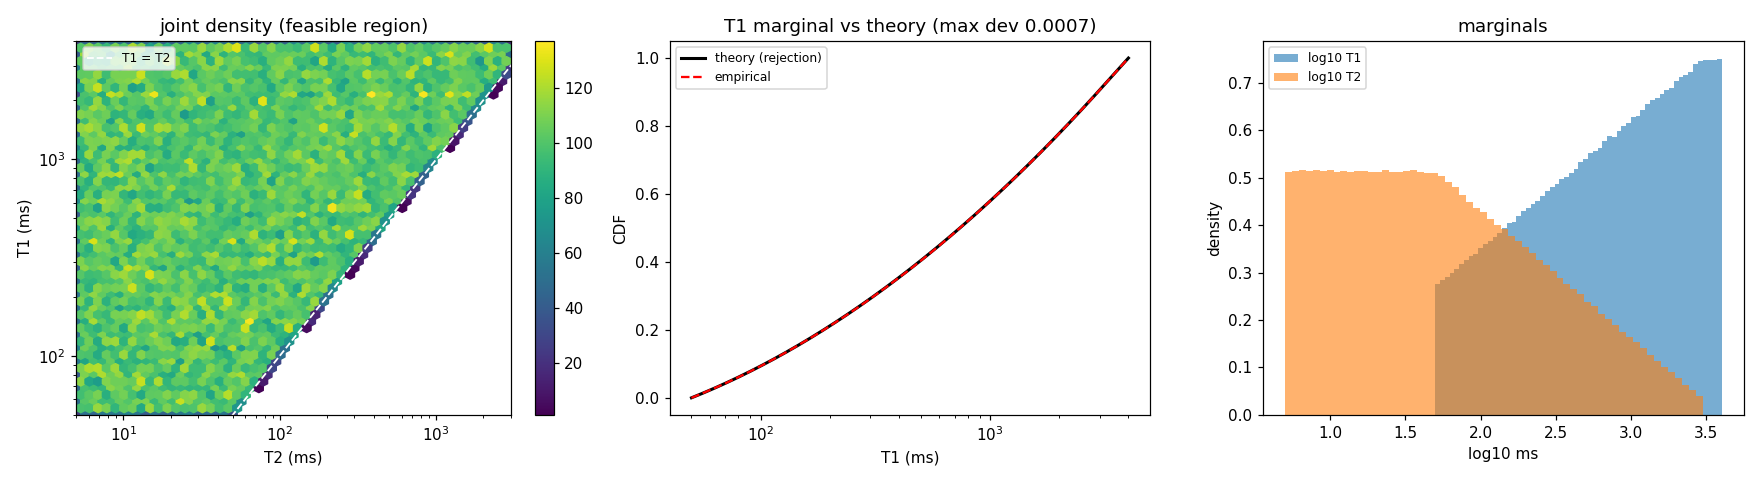

In [5]:
def all_comps(split="train"):
    t1, t2, w = [], [], []
    for n in N_VALUES:
        d = frames[(n, split)]
        for i in range(1, n + 1):
            t1.append(d[f"T1_{i}"].to_numpy()); t2.append(d[f"T2_{i}"].to_numpy()); w.append(d[f"w_{i}"].to_numpy())
    return np.concatenate(t1), np.concatenate(t2), np.concatenate(w)

T1A, T2A, WA = all_comps("train")
print(f"{len(T1A):,} compartments in train")

# Theoretical accepted-T1 density: uniform in log t1, weighted by P(t2 < t1) under log-uniform t2.
lo1, hi1 = T1_RANGE; lo2, hi2 = T2_RANGE
grid = np.linspace(np.log(lo1), np.log(hi1), 4000)
p_accept = (np.minimum(np.log(hi2), grid) - np.log(lo2)) / (np.log(hi2) - np.log(lo2))
p_accept = np.clip(p_accept, 0, 1)
cdf_theory = np.cumsum(p_accept); cdf_theory /= cdf_theory[-1]
emp = np.searchsorted(np.sort(np.log(T1A)), grid) / len(T1A)
max_dev = float(np.abs(emp - cdf_theory).max())

check("T1 marginal matches the rejection-sampling theory", max_dev < 0.01, f"max CDF dev {max_dev:.4f}")
frac_short = float((T1A < 200).mean())
check("short-T1 oversampling is gone", 0.18 < frac_short < 0.24,
      f"frac T1<200ms = {frac_short:.3f} (clipping gave ~0.314)")

idx = np.random.default_rng(0).choice(len(T1A), min(SAMPLE_FOR_PLOTS, len(T1A)), replace=False)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
hb = ax[0].hexbin(T2A[idx], T1A[idx], xscale="log", yscale="log", gridsize=50, cmap="viridis", mincnt=1)
ax[0].plot([5, 4000], [5, 4000], "w--", lw=1.2, label="T1 = T2")
ax[0].set_xlim(lo2, hi2); ax[0].set_ylim(lo1, hi1)
ax[0].set_xlabel("T2 (ms)"); ax[0].set_ylabel("T1 (ms)"); ax[0].set_title("joint density (feasible region)")
ax[0].legend(loc="upper left", fontsize=8); fig.colorbar(hb, ax=ax[0], fraction=0.046)

ax[1].plot(np.exp(grid), cdf_theory, "k-", lw=2, label="theory (rejection)")
ax[1].plot(np.exp(grid), emp, "r--", lw=1.5, label="empirical")
ax[1].set_xscale("log"); ax[1].set_xlabel("T1 (ms)"); ax[1].set_ylabel("CDF")
ax[1].set_title(f"T1 marginal vs theory (max dev {max_dev:.4f})"); ax[1].legend(fontsize=8)

ax[2].hist(np.log10(T1A), bins=60, alpha=0.6, label="log10 T1", density=True)
ax[2].hist(np.log10(T2A), bins=60, alpha=0.6, label="log10 T2", density=True)
ax[2].set_xlabel("log10 ms"); ax[2].set_ylabel("density"); ax[2].set_title("marginals")
ax[2].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "coverage.png", dpi=110); plt.close(fig)
Image(filename=str(FIG / "coverage.png"))

### Cross-n consistency

The same sampler draws the compartments for every file; only the *count* differs. So the per-n
T1/T2 marginals must be statistically identical. A divergence here means the count is leaking into
the parameter draw — i.e. the threading or the seed derivation is wrong. This is the cheapest check
that the whole per-n design is sound on real data.

(Weight histograms *will* legitimately differ by n — Dirichlet(1ⁿ) with a floor — so those are
compared per-n, never across.)

param     pair     KS
   T1 n1 vs n2 0.0029
   T1 n1 vs n3 0.0019
   T1 n1 vs n4 0.0020
   T2 n1 vs n2 0.0022
   T2 n1 vs n3 0.0016
   T2 n1 vs n4 0.0024

  PASS  cross-n T1/T2 marginals agree (KS < 0.01)   [worst KS 0.0029]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


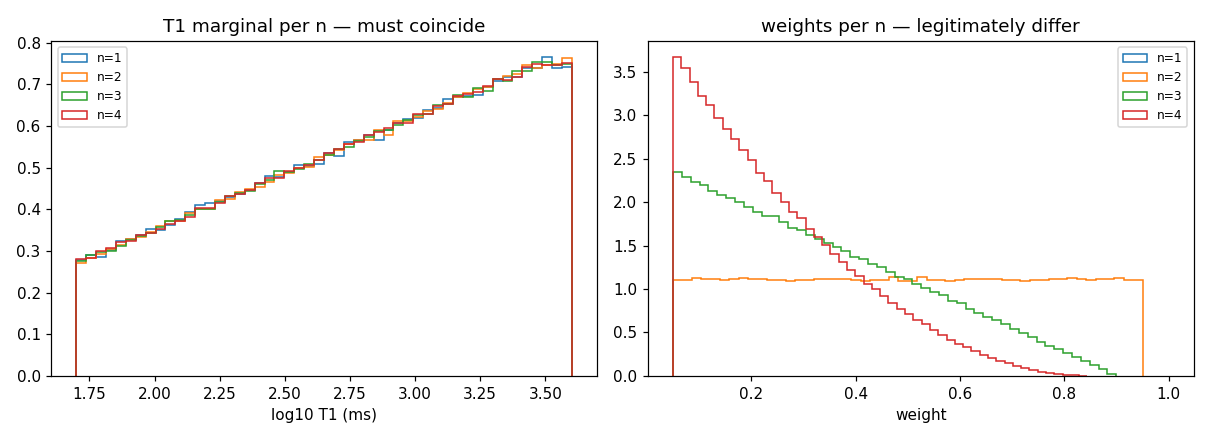

In [6]:
def comps_of(n, col):
    d = frames[(n, "train")]
    return np.concatenate([d[f"{col}_{i}"].dropna().to_numpy() for i in range(1, n + 1)])

ks_rows, worst = [], 0.0
for col in ("T1", "T2"):
    base = comps_of(N_VALUES[0], col)
    for n in N_VALUES[1:]:
        ks = float(ks_2samp(base, comps_of(n, col)).statistic)
        worst = max(worst, ks)
        ks_rows.append({"param": col, "pair": f"n{N_VALUES[0]} vs n{n}", "KS": round(ks, 4)})
print(pd.DataFrame(ks_rows).to_string(index=False)); print()
check("cross-n T1/T2 marginals agree (KS < 0.01)", worst < 0.01, f"worst KS {worst:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for n in N_VALUES:
    ax[0].hist(np.log10(comps_of(n, "T1")), bins=50, histtype="step", density=True, label=f"n={n}")
    d = frames[(n, "train")]
    ws = np.concatenate([d[f"w_{i}"].dropna().to_numpy() for i in range(1, n + 1)])
    ax[1].hist(ws, bins=50, histtype="step", density=True, label=f"n={n}")
ax[0].set_xlabel("log10 T1 (ms)"); ax[0].set_title("T1 marginal per n — must coincide"); ax[0].legend(fontsize=8)
ax[1].set_xlabel("weight"); ax[1].set_title("weights per n — legitimately differ"); ax[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "cross_n.png", dpi=110); plt.close(fig)
Image(filename=str(FIG / "cross_n.png"))

## 5. Noise: is it really N(0, sigma) on a signed signal?

Re-synthesize the clean signal from the stored ground truth and standardize the residual. The
forward model here is `t1t2.physics`, which is parity-tested against the generator's own — so this
is a genuine independent check that the stored signal, the stored sigma and the stored targets are
mutually consistent, not just a restatement of how they were made.

standardized residual over 1,024,000 points: mean=-0.0004  std=1.0005
  PASS  residual is zero-mean   [mean -0.0004]
  PASS  residual has unit variance   [std 1.0005]
  PASS  the signal really is signed (IR goes negative)   [61.7% of samples negative]


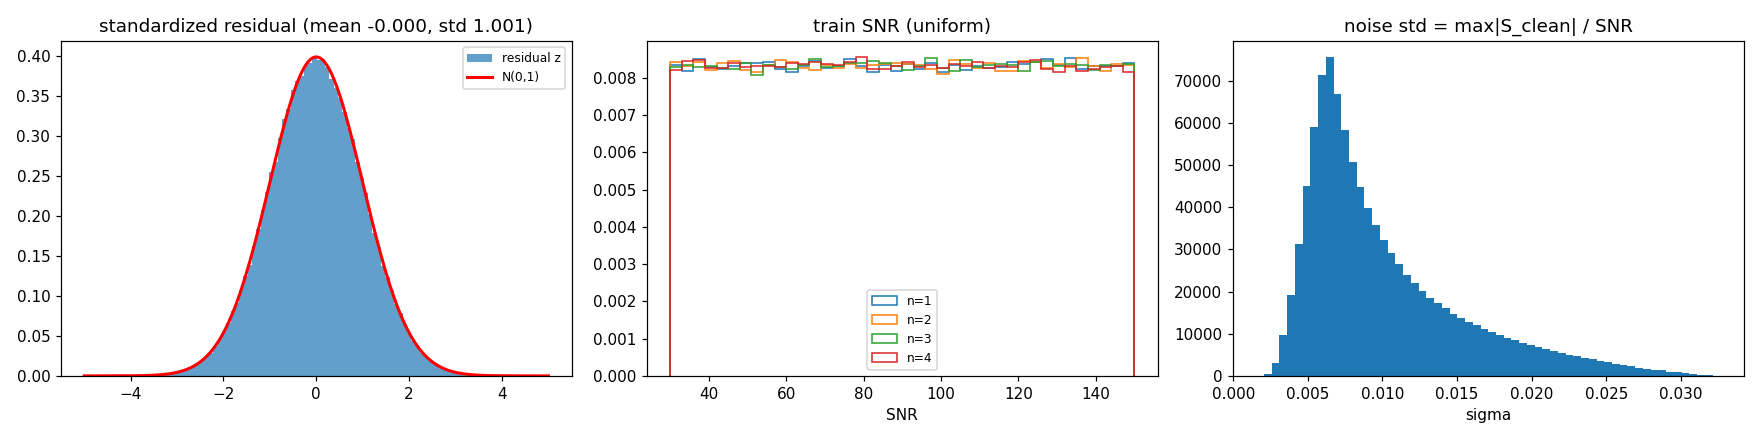

In [7]:
from t1t2.physics import forward_numpy, load_protocol

proto = load_protocol()

def residual_z(n, split, cap=4000):
    d = frames[(n, split)] if (n, split) in frames else load(n, split)
    d = d.iloc[:cap]
    S = d[SCOLS].to_numpy(np.float64)
    Z = np.empty_like(S)
    for r in range(len(d)):
        k = int(d.n_comp.iloc[r])
        t1 = d[[f"T1_{i+1}" for i in range(k)]].iloc[r].to_numpy(float)
        t2 = d[[f"T2_{i+1}" for i in range(k)]].iloc[r].to_numpy(float)
        w = d[[f"w_{i+1}" for i in range(k)]].iloc[r].to_numpy(float)
        Z[r] = (S[r] - forward_numpy(proto, t1, t2, w)) / d.sigma.iloc[r]
    return Z

zs = {n: residual_z(n, "train") for n in N_VALUES}
allz = np.concatenate([z.ravel() for z in zs.values()])
mz, sz = float(allz.mean()), float(allz.std())
print(f"standardized residual over {allz.size:,} points: mean={mz:+.4f}  std={sz:.4f}")
check("residual is zero-mean", abs(mz) < 0.01, f"mean {mz:+.4f}")
check("residual has unit variance", 0.98 < sz < 1.02, f"std {sz:.4f}")

d0 = frames[(N_VALUES[-1], "train")]
signed_frac = float((d0[SCOLS].to_numpy() < 0).mean())
check("the signal really is signed (IR goes negative)", signed_frac > 0.05,
      f"{signed_frac*100:.1f}% of samples negative")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(allz[np.random.default_rng(0).choice(allz.size, min(300_000, allz.size), replace=False)],
           bins=100, density=True, alpha=0.7, label="residual z")
xs = np.linspace(-5, 5, 200)
ax[0].plot(xs, np.exp(-xs**2 / 2) / np.sqrt(2 * np.pi), "r-", lw=2, label="N(0,1)")
ax[0].set_title(f"standardized residual (mean {mz:+.3f}, std {sz:.3f})"); ax[0].legend(fontsize=8)

for n in N_VALUES:
    ax[1].hist(frames[(n, "train")].snr, bins=40, histtype="step", density=True, label=f"n={n}")
ax[1].set_xlabel("SNR"); ax[1].set_title("train SNR (uniform)"); ax[1].legend(fontsize=8)

ax[2].hist(np.concatenate([frames[(n, "train")].sigma.to_numpy() for n in N_VALUES]), bins=60)
ax[2].set_xlabel("sigma"); ax[2].set_title("noise std = max|S_clean| / SNR")
fig.tight_layout(); fig.savefig(FIG / "noise.png", dpi=110); plt.close(fig)
Image(filename=str(FIG / "noise.png"))

## 6. The protocol and the 64 measurement positions

The 8×8 grid is shown in **scanner order** — never re-sorted. Input position *p* must mean the same
(TI_p, TE_p) at train and inference time, so a "tidier" ordering here would be a silent correctness
bug.

 pos     TI    TE   mean   std    q05   q95  neg_frac
   1  412.0 150.0 -0.077 0.158 -0.418 0.096     0.658
   2 1181.0  20.0  0.217 0.269 -0.210 0.694     0.202
   3  412.0  55.0 -0.081 0.224 -0.513 0.262     0.621
   4  412.0  91.0 -0.082 0.189 -0.469 0.170     0.641
   5  243.0   7.5 -0.205 0.367 -0.747 0.467     0.721
   6   50.0 150.0 -0.197 0.217 -0.660 0.005     0.895
   7 1181.0   7.5  0.321 0.321 -0.235 0.828     0.178
   8 2000.0  55.0  0.211 0.201 -0.012 0.610     0.092
  ...
  PASS  no measurement position is constant
  PASS  negative samples concentrate at short TI (IR physics)


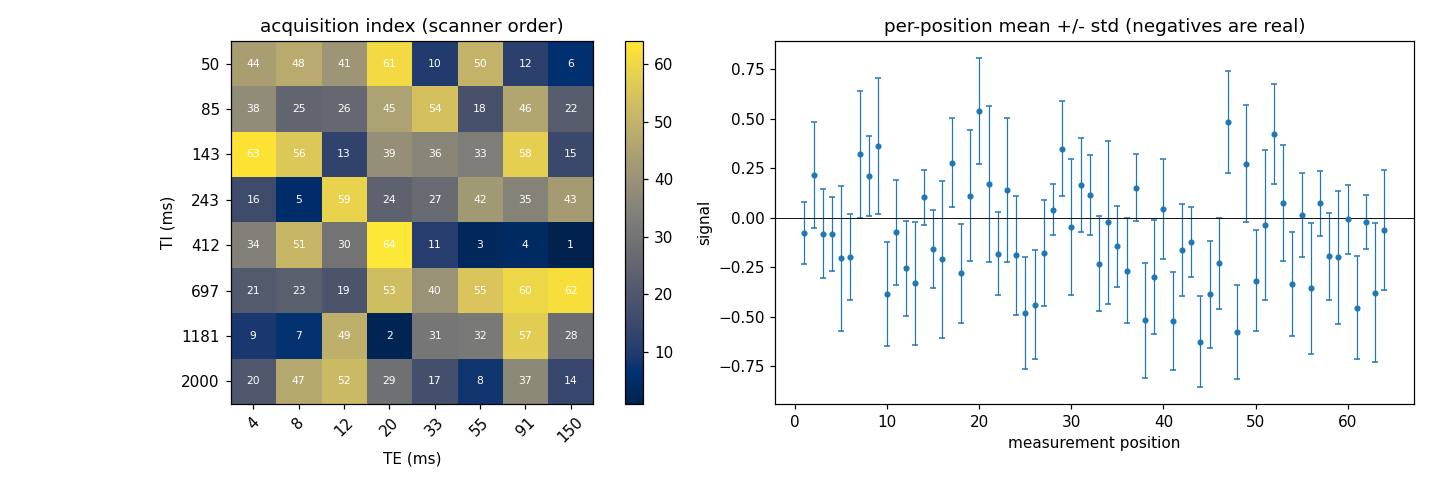

In [8]:
S = np.concatenate([frames[(n, "train")][SCOLS].to_numpy(np.float64) for n in N_VALUES])
pos = pd.DataFrame({
    "pos": np.arange(1, 65), "TI": proto.ti, "TE": proto.te,
    "mean": S.mean(0).round(3), "std": S.std(0).round(3),
    "q05": np.quantile(S, 0.05, axis=0).round(3), "q95": np.quantile(S, 0.95, axis=0).round(3),
    "neg_frac": (S < 0).mean(0).round(3),
})
print(pos.head(8).to_string(index=False)); print("  ...")
check("no measurement position is constant", bool((pos["std"] > 1e-6).all()))
check("negative samples concentrate at short TI (IR physics)",
      pos.loc[pos.TI < 300, "neg_frac"].mean() > pos.loc[pos.TI > 1000, "neg_frac"].mean())

uti, ute = np.unique(proto.ti), np.unique(proto.te)
order = np.full((8, 8), np.nan)
for p in range(64):
    order[int(np.argmin(abs(uti - proto.ti[p]))), int(np.argmin(abs(ute - proto.te[p])))] = p + 1

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
im = ax[0].imshow(order, cmap="cividis")
for i in range(8):
    for j in range(8):
        ax[0].text(j, i, f"{int(order[i,j])}", ha="center", va="center", fontsize=7, color="w")
ax[0].set_xticks(range(8)); ax[0].set_xticklabels([f"{t:.0f}" for t in ute], rotation=45)
ax[0].set_yticks(range(8)); ax[0].set_yticklabels([f"{t:.0f}" for t in uti])
ax[0].set_xlabel("TE (ms)"); ax[0].set_ylabel("TI (ms)"); ax[0].set_title("acquisition index (scanner order)")
fig.colorbar(im, ax=ax[0], fraction=0.046)

ax[1].errorbar(pos.pos, pos["mean"], yerr=pos["std"], fmt="o", ms=3, lw=0.8, capsize=2)
ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_xlabel("measurement position"); ax[1].set_ylabel("signal")
ax[1].set_title("per-position mean +/- std (negatives are real)")
fig.tight_layout(); fig.savefig(FIG / "protocol.png", dpi=110); plt.close(fig)
Image(filename=str(FIG / "protocol.png"))

## 7. Identifiability: how hard is this data, honestly?

Two things that are **not** defects but which decide how the results must be read:

- **Nearest-compartment distance.** Compartments are drawn independently with no minimum
  separation, so some voxels contain pairs that no method could resolve at any SNR. Reported as a
  continuous distribution; no threshold, no merging, no twin metric — the model is asked to find
  what the ground truth says is there.
- **Detectability.** Remove each voxel's *smallest* compartment and compare the change in signal to
  the noise. Where Δ < σ, that compartment is below the noise floor: the count is not recoverable,
  and a low per-n accuracy there is a property of the data, not a failure of the model.

 n  nearest_dist_median  frac_pairs_within_0.2  delta_over_sigma_median@SNR20  frac_below_noise_floor
 1                  NaN                    NaN                            NaN                     NaN
 2                2.392                 0.0067                           1.96                   0.274
 3                1.314                 0.0163                           1.06                   0.478
 4                0.877                 0.0333                           0.68                   0.693

'frac_below_noise_floor' is the ceiling on count accuracy at that n — not a model failure.


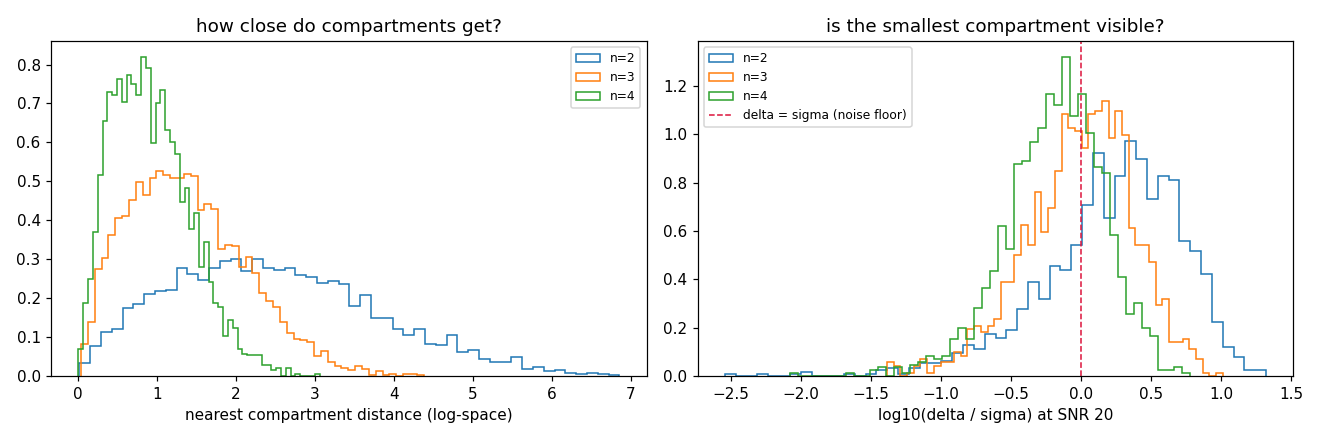

In [9]:
def nearest_dist(n):
    d = frames[(n, "train")].iloc[:4000]
    if n < 2:
        return np.array([])
    lt1 = np.log(np.stack([d[f"T1_{i+1}"].to_numpy(float) for i in range(n)], 1))
    lt2 = np.log(np.stack([d[f"T2_{i+1}"].to_numpy(float) for i in range(n)], 1))
    out = np.full(len(d), np.inf)
    for a in range(n):
        for b in range(a + 1, n):
            dist = np.sqrt((lt1[:, a] - lt1[:, b])**2 + (lt2[:, a] - lt2[:, b])**2)
            out = np.minimum(out, dist)
    return out

def detectability(n, snr=20.0):
    # Delta/sigma when the smallest-weight compartment is dropped: is it visible at all?
    d = frames[(n, "train")].iloc[:1500]
    if n < 2:
        return np.array([])
    ratios = []
    for r in range(len(d)):
        t1 = d[[f"T1_{i+1}" for i in range(n)]].iloc[r].to_numpy(float)
        t2 = d[[f"T2_{i+1}" for i in range(n)]].iloc[r].to_numpy(float)
        w = d[[f"w_{i+1}" for i in range(n)]].iloc[r].to_numpy(float)
        full = forward_numpy(proto, t1, t2, w)
        k = int(np.argmin(w))
        keep = np.ones(n, bool); keep[k] = False
        w2 = w[keep] / w[keep].sum()
        red = forward_numpy(proto, t1[keep], t2[keep], w2)
        sigma = np.max(np.abs(full)) / snr
        ratios.append(np.median(np.abs(full - red)) / sigma)
    return np.array(ratios)

rows = []
for n in N_VALUES:
    nd, det = nearest_dist(n), detectability(n)
    rows.append({
        "n": n,
        "nearest_dist_median": round(float(np.median(nd)), 3) if nd.size else None,
        "frac_pairs_within_0.2": round(float((nd < 0.2).mean()), 4) if nd.size else None,
        "delta_over_sigma_median@SNR20": round(float(np.median(det)), 2) if det.size else None,
        "frac_below_noise_floor": round(float((det < 1).mean()), 3) if det.size else None,
    })
ident = pd.DataFrame(rows)
print(ident.to_string(index=False))
print("\n'frac_below_noise_floor' is the ceiling on count accuracy at that n — not a model failure.")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for n in N_VALUES:
    nd = nearest_dist(n)
    if nd.size:
        ax[0].hist(nd, bins=50, histtype="step", density=True, label=f"n={n}")
    det = detectability(n)
    if det.size:
        ax[1].hist(np.log10(np.clip(det, 1e-3, None)), bins=50, histtype="step", density=True, label=f"n={n}")
ax[0].set_xlabel("nearest compartment distance (log-space)"); ax[0].set_title("how close do compartments get?")
ax[0].legend(fontsize=8)
ax[1].axvline(0, color="crimson", ls="--", lw=1, label="delta = sigma (noise floor)")
ax[1].set_xlabel("log10(delta / sigma) at SNR 20"); ax[1].set_title("is the smallest compartment visible?")
ax[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "identifiability.png", dpi=110); plt.close(fig)
Image(filename=str(FIG / "identifiability.png"))

## 8. Leakage, and the paired SNR ladder

Splits are separated by their *split code*, which is part of every RNG stream key, so they cannot
overlap by construction. This section checks that the construction actually held, by hashing the
ground truth.

The ladder is the opposite case: its rungs are *supposed* to share ground truth with each other —
that is what makes the SNR sweep a paired comparison rather than five unrelated samples. So the
leakage check for the ladder is against train/val/test, never rung-vs-rung.

In [10]:
def gt_hashes(n, split):
    d = frames[(n, split)] if (n, split) in frames else load(n, split)
    cols = [f"{p}_{i}" for p in ("T1", "T2", "w") for i in range(1, MAX_COMP + 1)]
    arr = np.ascontiguousarray(d[cols].to_numpy(np.float64))
    return {hashlib.blake2b(row.tobytes(), digest_size=16).hexdigest() for row in arr}

H = {(n, s): gt_hashes(n, s) for n in N_VALUES for s in SPLITS}
worst = 0
for n in N_VALUES:
    for a, b in (("train", "val"), ("train", "test"), ("val", "test")):
        worst = max(worst, len(H[(n, a)] & H[(n, b)]))
check("no ground-truth leakage among train/val/test", worst == 0, f"max overlap {worst}")

if LADDER:
    lad = {(n, s): gt_hashes(n, s) for n in N_VALUES for s in LADDER}
    cross = 0
    for n in N_VALUES:
        for s in LADDER:
            for split in SPLITS:
                cross = max(cross, len(lad[(n, s)] & H[(n, split)]))
    check("SNR ladder shares no ground truth with train/val/test", cross == 0, f"max overlap {cross}")

    same_gt, z_dev = True, 0.0
    for n in N_VALUES:
        gt_cols = ["n_comp"] + [f"{p}_{i}" for p in ("T1", "T2", "w") for i in range(1, MAX_COMP + 1)]
        ref = load(n, LADDER[0])
        zref = residual_z(n, LADDER[0], cap=300)
        for s in LADDER[1:]:
            cur = load(n, s)
            same_gt &= ref[gt_cols].equals(cur[gt_cols])
            z_dev = max(z_dev, float(np.abs(zref - residual_z(n, s, cap=300)).max()))
    check("every ladder rung holds the SAME voxels (paired design)", same_gt)
    # Ground truth is float64 and matches exactly; z is recovered through float32 signals, so
    # 1/sigma amplifies storage rounding to ~2e-5 at SNR 150. Compare with a tolerance.
    check("every ladder rung holds the same standardized noise z", z_dev < 1e-4,
          f"max |z_i - z_0| = {z_dev:.2e} (float32 storage bound ~2e-5)")

    sig = pd.DataFrame([{"rung": s, "snr": load(n, s).snr.iloc[0],
                         "sigma_median": round(float(load(n, s).sigma.median()), 5)}
                        for s in LADDER for n in N_VALUES[:1]])
    print(); print(sig.to_string(index=False))
    check("sigma falls as SNR rises", bool((sig.sort_values("snr").sigma_median.diff().dropna() < 0).all()))

  PASS  no ground-truth leakage among train/val/test   [max overlap 0]


  PASS  SNR ladder shares no ground truth with train/val/test   [max overlap 0]


  PASS  every ladder rung holds the SAME voxels (paired design)
  PASS  every ladder rung holds the same standardized noise z   [max |z_i - z_0| = 7.97e-06 (float32 storage bound ~2e-5)]

       rung   snr  sigma_median
 test_snr20  20.0       0.04337
 test_snr40  40.0       0.02169
 test_snr60  60.0       0.01446
test_snr100 100.0       0.00867
test_snr150 150.0       0.00578
  PASS  sigma falls as SNR rises


## 9. Verdict

Anything failing here blocks the run. A dataset that fails is cheaper to regenerate than a training
run built on it is to debug.

In [11]:
res = pd.DataFrame(CHECKS)
res["status"] = np.where(res["pass"], "PASS", np.where(res["hard"], "FAIL", "WARN"))
n_fail = int((~res["pass"] & res["hard"]).sum())
n_warn = int((~res["pass"] & ~res["hard"]).sum())

print(res[["status", "check", "detail"]].to_string(index=False))
print()
print("=" * 78)
verdict = ("dataset is fit to train on" if n_fail == 0 else f"{n_fail} HARD CHECK(S) FAILED: DO NOT TRAIN")
print(f"  {int(res['pass'].sum())}/{len(res)} passed, {n_warn} warning(s)  ->  {verdict}")
print("=" * 78)

summary = {
    "data_root": str(DATA), "n_values": N_VALUES,
    "train_total": int(train_total),
    "checks_total": len(res), "checks_failed": n_fail, "warnings": n_warn, "passed": n_fail == 0,
    "require_clean": REQUIRE_CLEAN,
    "coverage_max_cdf_dev": max_dev, "cross_n_worst_ks": worst if isinstance(worst, float) else None,
    "residual_mean": mz, "residual_std": sz,
    "identifiability": ident.to_dict("records"),
    "failed": res.loc[~res["pass"] & res["hard"], "check"].tolist(),
    "warned": res.loc[~res["pass"] & ~res["hard"], "check"].tolist(),
}
with open(OUT / "audit_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(f"\nsummary + figures -> {OUT}")

# Raise, so a headless run fails loudly instead of producing a green-looking notebook nobody read.
assert n_fail == 0, f"{n_fail} hard audit check(s) failed — see the table above. Do not submit training."


status                                                   check                                                       detail
  PASS                            manifest present for every n                                                          4/4
  PASS                      manifest n_comp matches its folder                                                             
  PASS                    protocol checksum identical across n                                                             
  PASS               protocol matches the one in this checkout                                                 78ab7a82ce2c
  PASS                        all families share one base seed                                                             
  PASS                      stream ids are the documented ones                                                             
  PASS                         generated from a clean worktree dirty => the code that made this is not what any commit says
  PASS  

## What this notebook is for

- It is the **gate**: full GPU training is not submitted until every check above is green *and* a
  human has read the figures. The final cell raises, so a headless run fails loudly rather than
  producing a green-looking notebook nobody checked.
- It is also the **data inspector**: point `AUDIT_DATA_ROOT` at another family
  when you want to inspect a different generated dataset.
- Two sections are not pass/fail but decide how results get reported: §4's coverage (neither
  marginal is log-uniform — say so in the thesis) and §7's identifiability (the per-n ceiling is a
  property of the data, so results must be read per-n).